In [2]:
# Author:      Wajid Ali Saleem Chaudhry
# Description: Pharmaceutical sales data analysis using pandas
#              and matplotlib across 8 ATC drug categories.

## Setup — imports & dataset load

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/salesdaily.csv",parse_dates=["datum"],index_col="datum")

df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
DatetimeIndex: 2106 entries, 2014-01-02 to 2019-10-08
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   M01AB         2106 non-null   float64
 1   M01AE         2106 non-null   float64
 2   N02BA         2106 non-null   float64
 3   N02BE         2106 non-null   float64
 4   N05B          2106 non-null   float64
 5   N05C          2106 non-null   float64
 6   R03           2106 non-null   float64
 7   R06           2106 non-null   float64
 8   Year          2106 non-null   int64  
 9   Month         2106 non-null   int64  
 10  Hour          2106 non-null   int64  
 11  Weekday Name  2106 non-null   str    
dtypes: float64(8), int64(3), str(1)
memory usage: 213.9 KB


,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour
count,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000
mean,5.033683,3.895830,3.880441,29.917095,8.853627,0.593522,5.512262,2.900198,2016.401235,6.344255,275.945869
std,2.737579,2.133337,2.384010,15.590966,5.605605,1.092988,6.428736,2.415816,1.665060,3.386954,1.970547
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2014.000000,1.000000,190.000000
25%,3.000000,2.340000,2.000000,19.000000,5.000000,0.000000,1.000000,1.000000,2015.000000,3.000000,276.000000
50%,4.990000,3.670000,3.500000,26.900000,8.000000,0.000000,4.000000,2.000000,2016.000000,6.000000,276.000000
75%,6.670000,5.138000,5.200000,38.300000,12.000000,1.000000,8.000000,4.000000,2018.000000,9.000000,276.000000
max,17.340000,14.463000,16.000000,161.000000,54.833333,9.000000,45.000000,15.000000,2019.000000,12.000000,276.000000


## Q1 — Total sales quantity by drug category (ATC code)

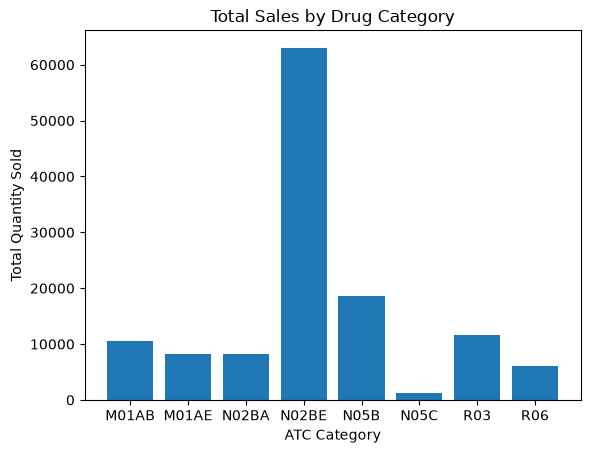

In [4]:
atc_cols = ["M01AB", "M01AE", "N02BA", "N02BE", "N05B", "N05C", "R03", "R06"]
totals = df[atc_cols].sum()

plt.bar(totals.index, totals.values)
plt.title("Total Sales by Drug Category")
plt.xlabel("ATC Category")
plt.ylabel("Total Quantity Sold")
plt.show()

*Answer:* **N02BE** has the highest total sales (~63,005 units). **N05C** is the lowest (~1,249 units).

## Q2 — Drug category with the highest total sales

In [5]:
best = totals.idxmax()
print(best)

N02BE


*Answer:* **N02BE** (analgesics/antipyretics — pyrazolones & anilides) has the highest total sales across the full dataset.

## Q3 — Top 3 drugs by sales in Jan 2015, Jul 2016, and Sep 2017

In [6]:
jan15 = df[(df["Year"] == 2015) & (df["Month"] == 1)]
jan15_totals = jan15[atc_cols].sum()
jan15_totals.nlargest(3)

jul16 = df[(df["Year"] == 2016) & (df["Month"] == 7)]
jul16_totals = jul16[atc_cols].sum()
jul16_totals.nlargest(3)

sept17 = df[(df["Year"] == 2017) & (df["Month"] == 9)]
sept17_totals = sept17[atc_cols].sum()
sept17_totals.nlargest(3)

print("Jan 2015:", jan15_totals.nlargest(3), sep="\n")
print("Jul 2016:", jul16_totals.nlargest(3), sep="\n")
print("Sep 2017:", sept17_totals.nlargest(3), sep="\n")

Jan 2015:
N02BE    1044.24
N05B      463.00
R03       177.25
dtype: float64
Jul 2016:
N02BE    652.362000
N05B     240.000000
M01AB    194.528333
dtype: float64
Sep 2017:
N02BE    863.75
N05B     223.00
R03      139.00
dtype: float64


*Answer:* **N02BE** topped all three months. Runners-up: Jan 2015 → N05B, R03; Jul 2016 → N05B, M01AB; Sep 2017 → N05B, R03.

## Q4 — Drug sold most frequently (highest total quantity) in 2017

In [7]:
year2017 = df[df["Year"] == 2017]
year2017_totals = year2017[atc_cols].sum()
year2017_totals.idxmax()


'N02BE'

*Answer:* **N02BE** had the highest total quantity sold in 2017.

## Q5 — Drug category with the highest average daily sales

In [8]:
daily_avg = df[atc_cols].mean()
daily_avg.idxmax()

'N02BE'

*Answer:* **N02BE** has the highest average daily sales (~29.9 units/day), over three times the next-highest category N05B (~8.9 units/day).

## Q6 — R03 (respiratory) seasonal sales pattern over the year

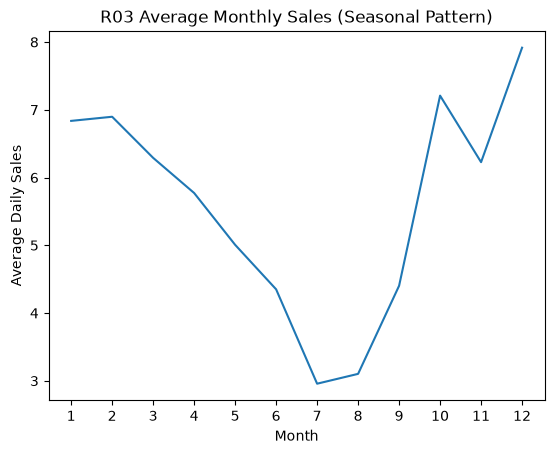

In [9]:
r03_monthly = df.groupby("Month")["R03"].mean()

plt.plot(r03_monthly.index, r03_monthly.values)
plt.title("R03 Average Monthly Sales (Seasonal Pattern)")
plt.xlabel("Month")
plt.ylabel("Average Daily Sales")
plt.xticks(range(1, 13))
plt.show()


*Answer:* R03 (respiratory) sales peak in winter (December ~7.9 units/day) and dip sharply in summer (July ~3.0 units/day), reflecting cold-weather demand for airway drugs.